In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
import os

In [2]:
df = pd.read_csv('../data/land_acquisition_india_200k_minimal/land_acquisition_india_200k.csv')

In [3]:
df.head()

,project_id,project_type,land_area_hectares,number_of_affected_families,compensation_status,approval_timeline_days,legal_disputes_count,possession_status,rehabilitation_progress_pct,stakeholder_responsiveness,historical_performance_score,administrator_id,manager,location,altitude_m,latitude,longitude,delay_status,delay_days,risk_score
0,LA-IND-0000001,Highway,41.58,9,Assessment/Processing,247,1,Acquired,63.5,Low,61.9,ADM-0290,MGR-05091,"Nainital, Uttarakhand",1612.9,30.0668,78.640313,Delayed,248,65.2
1,LA-IND-0000002,Railway,53.72,8,Paid in Full,223,1,Pending,67.3,Low,45.2,ADM-0350,MGR-10763,"Salem, Tamil Nadu",433.6,11.1271,77.155395,Delayed,186,65.7
2,LA-IND-0000003,Power,15.50,5,Not Started,172,1,Acquired,69.7,Medium,53.6,ADM-0040,MGR-05135,"Nainital, Uttarakhand",1512.9,30.0668,78.864017,On Time,55,58.5
3,LA-IND-0000004,Irrigation,31.00,11,Disputed,195,1,Partially Acquired,55.5,Medium,70.6,ADM-1065,MGR-05648,"Kamrup Metropolitan, Assam",259.6,26.2006,92.495593,On Time,47,60.8
4,LA-IND-0000005,Highway,110.35,123,Disputed,394,1,Acquired,80.0,Medium,53.9,ADM-1090,MGR-06966,"Khordha, Odisha",362.2,20.9517,85.049115,Delayed,248,66.4


In [4]:
df.shape

(200000, 20)

In [5]:
df.isnull().sum().sort_values(ascending=False)

project_id                      0
project_type                    0
land_area_hectares              0
number_of_affected_families     0
compensation_status             0
approval_timeline_days          0
legal_disputes_count            0
possession_status               0
rehabilitation_progress_pct     0
stakeholder_responsiveness      0
historical_performance_score    0
administrator_id                0
manager                         0
location                        0
altitude_m                      0
latitude                        0
longitude                       0
delay_status                    0
delay_days                      0
risk_score                      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["delay_status"].value_counts()

delay_status
On Time    136000
Delayed     64000
Name: count, dtype: int64

In [8]:
df["delay_status"].value_counts(normalize=True)

delay_status
On Time    0.68
Delayed    0.32
Name: proportion, dtype: float64

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
land_area_hectares,200000.0,64.393192,65.206044,0.950000,25.290000,45.020000,79.750000,1200.000000
number_of_affected_families,200000.0,42.022530,71.194418,1.000000,10.000000,22.000000,47.000000,4538.000000
approval_timeline_days,200000.0,243.967505,74.268002,15.000000,193.000000,236.000000,285.000000,1200.000000
legal_disputes_count,200000.0,1.597280,1.497310,0.000000,0.000000,1.000000,2.000000,22.000000
rehabilitation_progress_pct,200000.0,67.336788,19.998181,0.000000,54.100000,68.300000,82.200000,100.000000
historical_performance_score,200000.0,58.729159,14.279746,10.000000,49.200000,58.900000,68.500000,98.000000
altitude_m,200000.0,448.412172,510.092214,0.000000,128.400000,331.800000,573.625000,4293.100000
latitude,200000.0,22.269698,5.903773,10.566700,18.112400,22.973400,26.846700,34.152600
longitude,200000.0,80.160722,5.919266,69.475257,75.880617,78.703178,84.368628,96.847433
delay_days,200000.0,124.456540,142.911714,0.000000,27.000000,51.000000,233.000000,1214.000000


In [10]:
for col in df.select_dtypes(include="object"):
    print("\n", col)
    print(df[col].value_counts())

C:\Users\pankaj\AppData\Local\Temp\ipykernel_28112\1460546477.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):



 project_id
project_id
LA-IND-0000001    1
LA-IND-0000002    1
LA-IND-0000003    1
LA-IND-0000004    1
LA-IND-0000005    1
                 ..
LA-IND-0199996    1
LA-IND-0199997    1
LA-IND-0199998    1
LA-IND-0199999    1
LA-IND-0200000    1
Name: count, Length: 200000, dtype: int64

 project_type
project_type
Highway                 50009
Railway                 34310
Irrigation              24104
Other Infrastructure    19856
Urban Transport         17994
Power                   17779
Water Supply            14040
Industrial              13924
Airport                  7984
Name: count, dtype: int64

 compensation_status
compensation_status
Paid in Full             63940
Partially Paid           55906
Assessment/Processing    38031
Disputed                 21988
Not Started              20135
Name: count, dtype: int64

 possession_status
possession_status
Acquired              92083
Partially Acquired    46050
Pending               43907
Disputed/Stayed       17960
Name: count, dtyp

In [11]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().mean() * 100).values,
    "Unique Values": df.nunique().values
})

summary

,Column,Data Type,Missing Values,Missing %,Unique Values
0,project_id,str,0,0.0,200000
1,project_type,str,0,0.0,9
2,land_area_hectares,float64,0,0.0,24893
3,number_of_affected_families,int64,0,0.0,875
4,compensation_status,str,0,0.0,5
5,approval_timeline_days,int64,0,0.0,713
6,legal_disputes_count,int64,0,0.0,20
7,possession_status,str,0,0.0,4
8,rehabilitation_progress_pct,float64,0,0.0,1001
9,stakeholder_responsiveness,str,0,0.0,3


In [12]:
summary.to_csv("../data/processed/eda_column_summary.csv", index=False)

In [13]:
df["project_id"].duplicated().sum()

np.int64(0)

In [15]:
TARGET = "delay_status"
df[TARGET].value_counts(dropna=False)

delay_status
On Time    136000
Delayed     64000
Name: count, dtype: int64

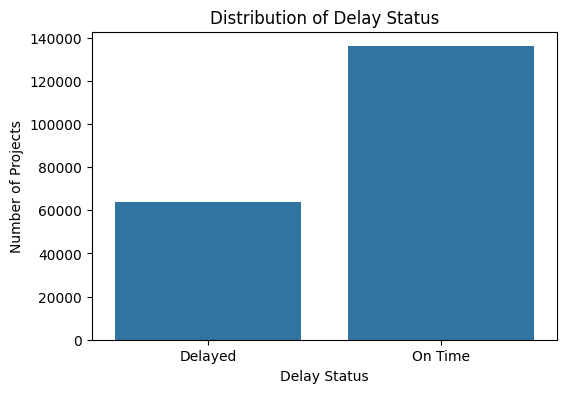

In [16]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x=TARGET)

plt.title("Distribution of Delay Status")
plt.xlabel("Delay Status")
plt.ylabel("Number of Projects")
plt.show()

In [17]:
df.groupby("delay_status")["delay_days"].describe()

,count,mean,std,min,25%,50%,75%,max
delay_status,,,,,,,,
Delayed,64000.0,312.802313,102.672944,123.0,240.0,293.0,365.0,1214.0
On Time,136000.0,35.823235,22.901590,0.0,18.0,35.0,52.0,89.0


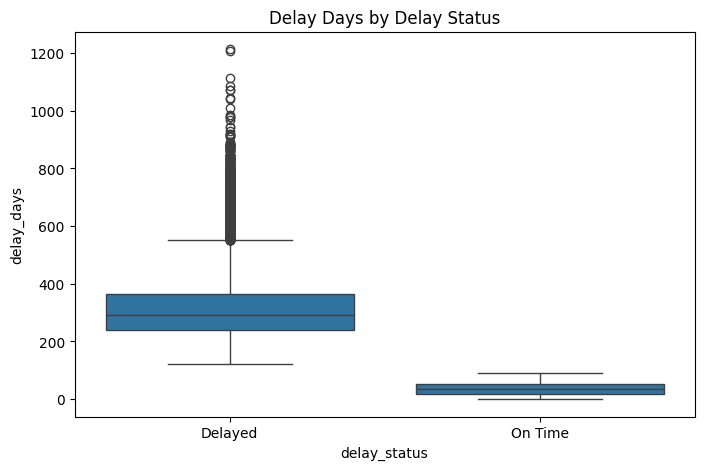

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="delay_status",
    y="delay_days"
)

plt.title("Delay Days by Delay Status")
plt.show()

In [19]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

numerical_columns

['land_area_hectares',
 'number_of_affected_families',
 'approval_timeline_days',
 'legal_disputes_count',
 'rehabilitation_progress_pct',
 'historical_performance_score',
 'altitude_m',
 'latitude',
 'longitude',
 'delay_days',
 'risk_score']

In [20]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
land_area_hectares,200000.0,64.393192,65.206044,0.950000,25.290000,45.020000,79.750000,1200.000000
number_of_affected_families,200000.0,42.022530,71.194418,1.000000,10.000000,22.000000,47.000000,4538.000000
approval_timeline_days,200000.0,243.967505,74.268002,15.000000,193.000000,236.000000,285.000000,1200.000000
legal_disputes_count,200000.0,1.597280,1.497310,0.000000,0.000000,1.000000,2.000000,22.000000
rehabilitation_progress_pct,200000.0,67.336788,19.998181,0.000000,54.100000,68.300000,82.200000,100.000000
historical_performance_score,200000.0,58.729159,14.279746,10.000000,49.200000,58.900000,68.500000,98.000000
altitude_m,200000.0,448.412172,510.092214,0.000000,128.400000,331.800000,573.625000,4293.100000
latitude,200000.0,22.269698,5.903773,10.566700,18.112400,22.973400,26.846700,34.152600
longitude,200000.0,80.160722,5.919266,69.475257,75.880617,78.703178,84.368628,96.847433
delay_days,200000.0,124.456540,142.911714,0.000000,27.000000,51.000000,233.000000,1214.000000


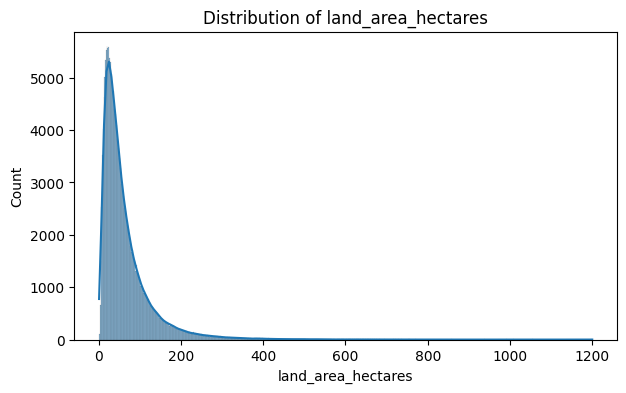

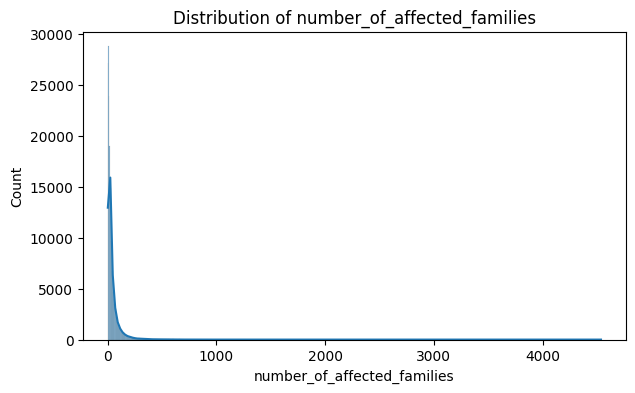

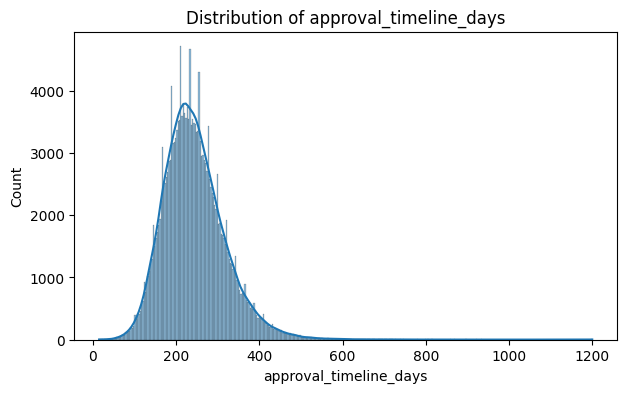

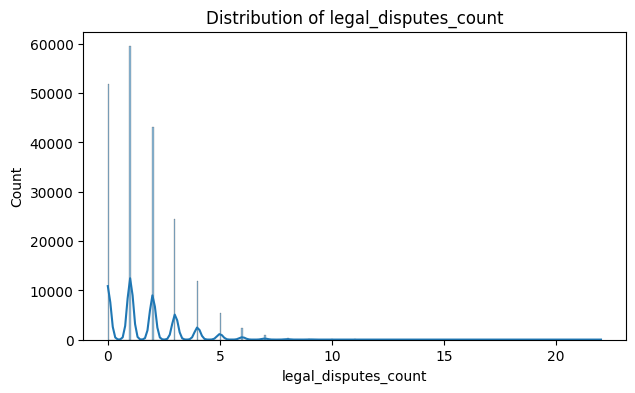

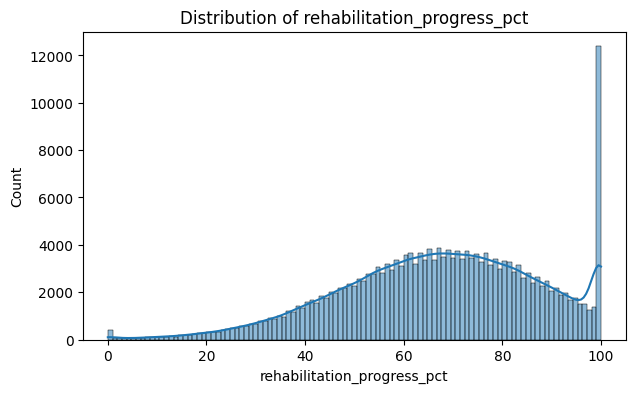

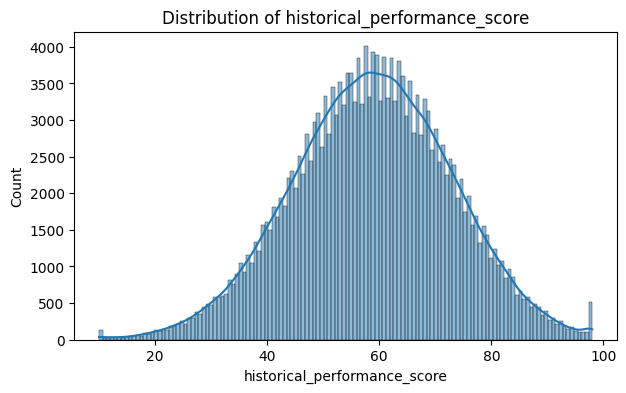

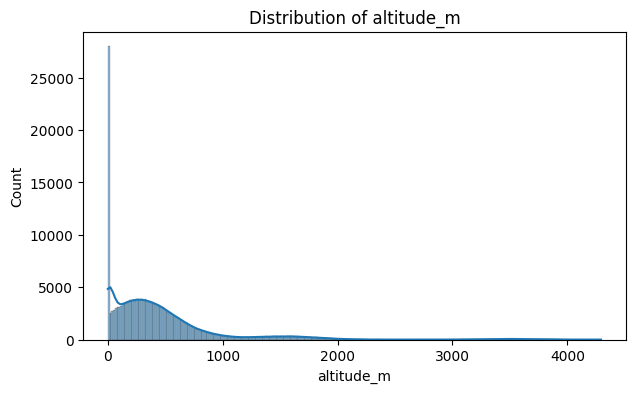

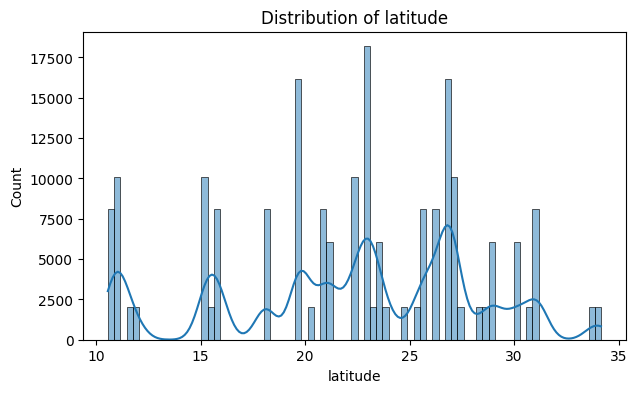

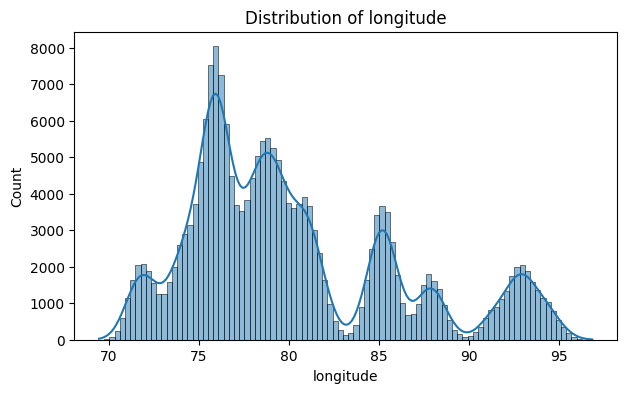

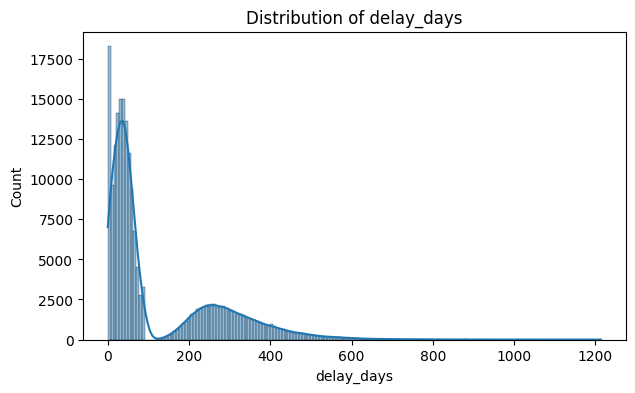

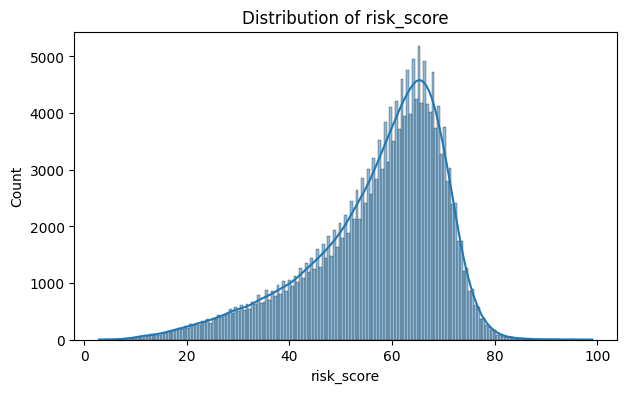

In [21]:
for col in numerical_columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [22]:
categorical_columns = df.select_dtypes(
    include="object"
).columns.tolist()

categorical_columns

C:\Users\pankaj\AppData\Local\Temp\ipykernel_28112\2183456383.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


['project_id',
 'project_type',
 'compensation_status',
 'possession_status',
 'stakeholder_responsiveness',
 'administrator_id',
 'manager',
 'location',
 'delay_status']

In [23]:
for col in categorical_columns:
    print(f"\n{'='*50}")
    print(col)
    print(df[col].value_counts(dropna=False).head(20))


project_id
project_id
LA-IND-0000001    1
LA-IND-0000002    1
LA-IND-0000003    1
LA-IND-0000004    1
LA-IND-0000005    1
LA-IND-0000006    1
LA-IND-0000007    1
LA-IND-0000008    1
LA-IND-0000009    1
LA-IND-0000010    1
LA-IND-0000011    1
LA-IND-0000012    1
LA-IND-0000013    1
LA-IND-0000014    1
LA-IND-0000015    1
LA-IND-0000016    1
LA-IND-0000017    1
LA-IND-0000018    1
LA-IND-0000019    1
LA-IND-0000020    1
Name: count, dtype: int64

project_type
project_type
Highway                 50009
Railway                 34310
Irrigation              24104
Other Infrastructure    19856
Urban Transport         17994
Power                   17779
Water Supply            14040
Industrial              13924
Airport                  7984
Name: count, dtype: int64

compensation_status
compensation_status
Paid in Full             63940
Partially Paid           55906
Assessment/Processing    38031
Disputed                 21988
Not Started              20135
Name: count, dtype: int64

posse

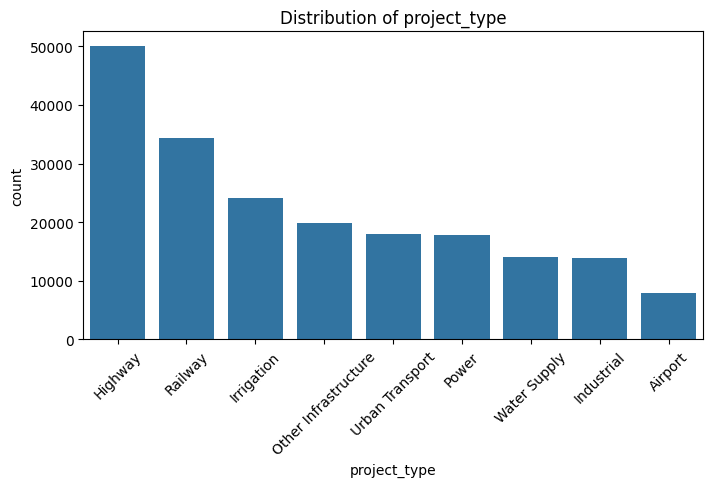

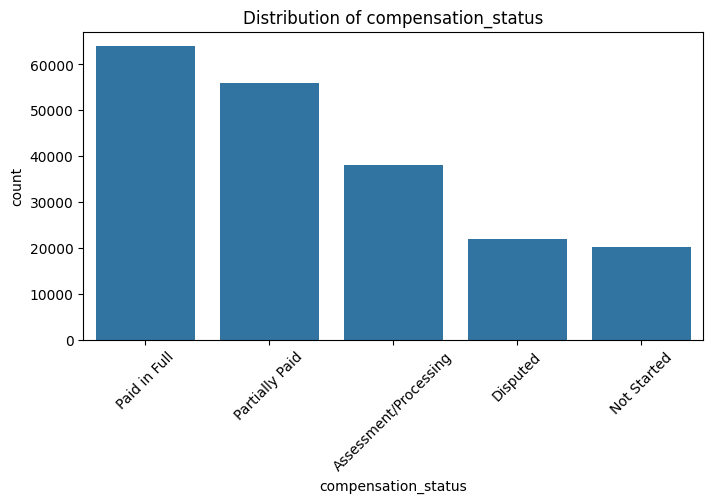

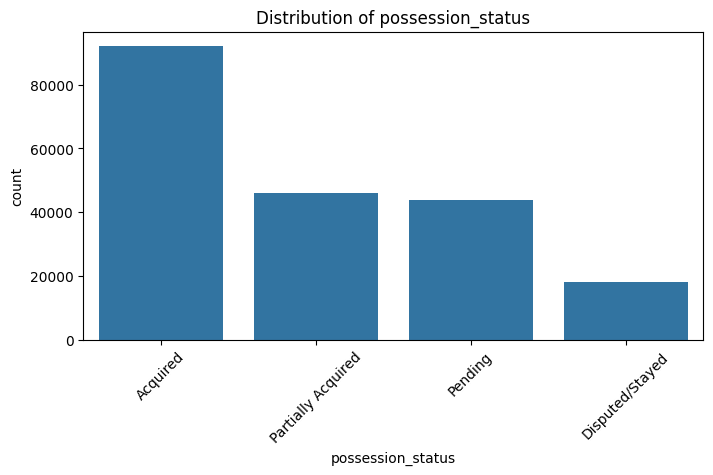

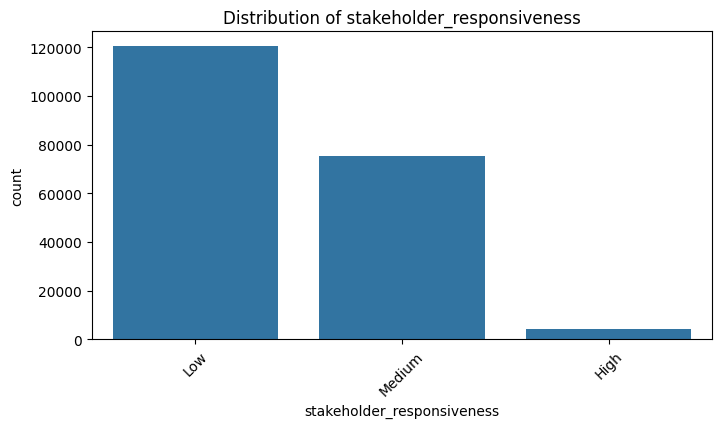

In [24]:
categorical_to_plot = [
    "project_type",
    "compensation_status",
    "possession_status",
    "stakeholder_responsiveness"
]

for col in categorical_to_plot:
    plt.figure(figsize=(8, 4))
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [25]:
pd.crosstab(
    df["project_type"],
    df["delay_status"],
    normalize="index"
) * 100

delay_status,Delayed,On Time
project_type,,
Airport,34.706914,65.293086
Highway,31.006419,68.993581
Industrial,31.865843,68.134157
Irrigation,27.995353,72.004647
Other Infrastructure,31.547139,68.452861
Power,25.068902,74.931098
Railway,31.702128,68.297872
Urban Transport,43.031010,56.968990
Water Supply,37.015670,62.984330


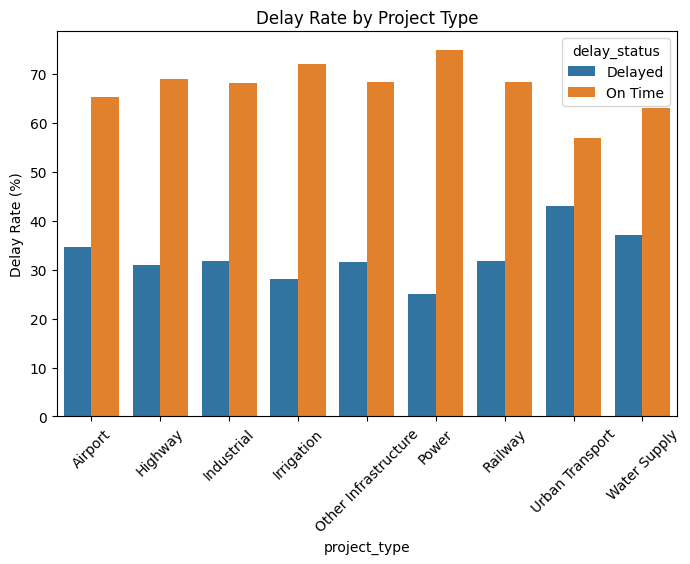

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crosstab with percentages
ct = pd.crosstab(
    df["project_type"],
    df["delay_status"],
    normalize="index"
) * 100

# Reset index so seaborn can use it
ct = ct.reset_index().melt(
    id_vars="project_type",
    var_name="delay_status",
    value_name="delay_rate"
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=ct,
    x="project_type",
    y="delay_rate",
    hue="delay_status"
)

plt.title("Delay Rate by Project Type")
plt.xticks(rotation=45)
plt.ylabel("Delay Rate (%)")
plt.show()


In [27]:
pd.crosstab(
    df["compensation_status"],
    df["delay_status"],
    normalize="index"
) * 100

delay_status,Delayed,On Time
compensation_status,,
Assessment/Processing,33.669901,66.330099
Disputed,48.994906,51.005094
Not Started,41.177055,58.822945
Paid in Full,26.847044,73.152956
Partially Paid,26.768147,73.231853


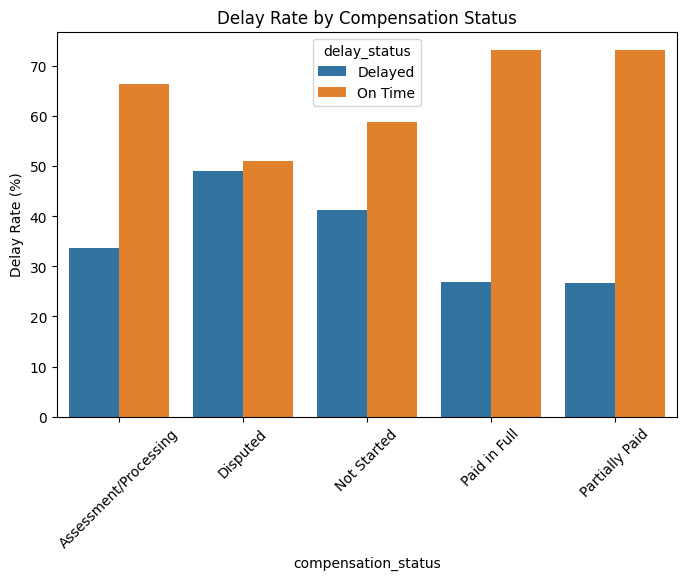

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crosstab with percentages
ct = pd.crosstab(
    df["compensation_status"],
    df["delay_status"],
    normalize="index"
) * 100

# Reset index so seaborn can use it
ct = ct.reset_index().melt(
    id_vars="compensation_status",
    var_name="delay_status",
    value_name="delay_rate"
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=ct,
    x="compensation_status",
    y="delay_rate",
    hue="delay_status"
)

plt.title("Delay Rate by Compensation Status")
plt.xticks(rotation=45)
plt.ylabel("Delay Rate (%)")
plt.show()


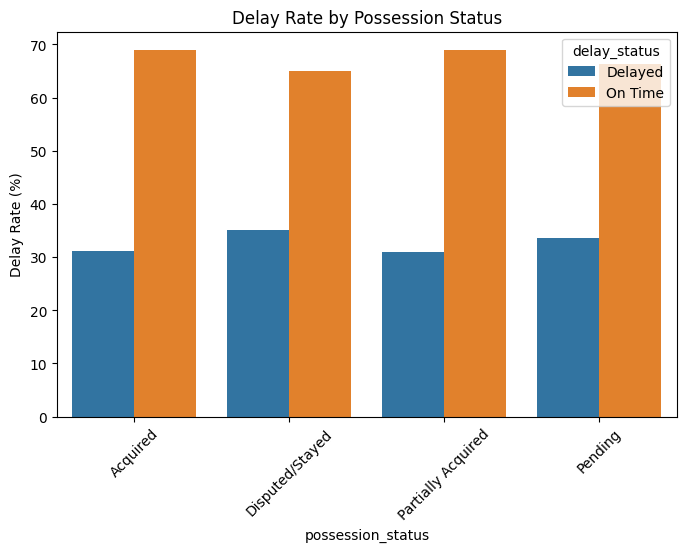

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crosstab with percentages
ct = pd.crosstab(
    df["possession_status"],
    df["delay_status"],
    normalize="index"
) * 100

# Reset index so seaborn can use it
ct = ct.reset_index().melt(
    id_vars="possession_status",
    var_name="delay_status",
    value_name="delay_rate"
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=ct,
    x="possession_status",
    y="delay_rate",
    hue="delay_status"
)

plt.title("Delay Rate by Possession Status")
plt.xticks(rotation=45)
plt.ylabel("Delay Rate (%)")
plt.show()


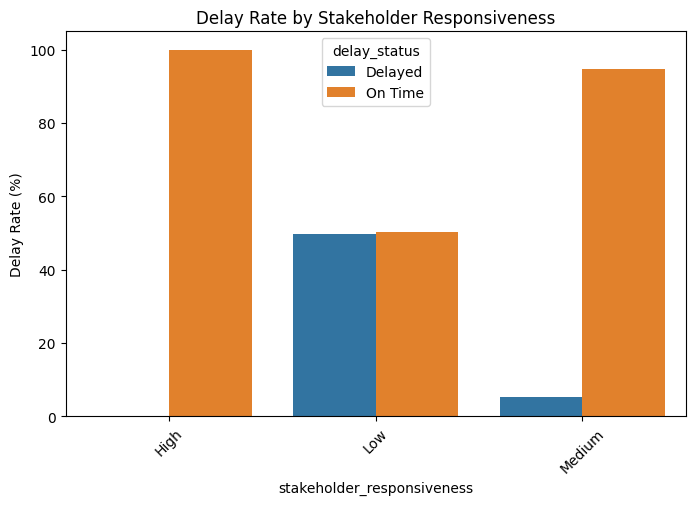

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crosstab with percentages
ct = pd.crosstab(
    df["stakeholder_responsiveness"],
    df["delay_status"],
    normalize="index"
) * 100

# Reset index so seaborn can use it
ct = ct.reset_index().melt(
    id_vars="stakeholder_responsiveness",
    var_name="delay_status",
    value_name="delay_rate"
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=ct,
    x="stakeholder_responsiveness",
    y="delay_rate",
    hue="delay_status"
)

plt.title("Delay Rate by Stakeholder Responsiveness")
plt.xticks(rotation=45)
plt.ylabel("Delay Rate (%)")
plt.show()


### Are delayed projects associated with more legal disputes?
### Do delayed projects have lower rehabilitation progress?
### Does historical performance relate to delay?

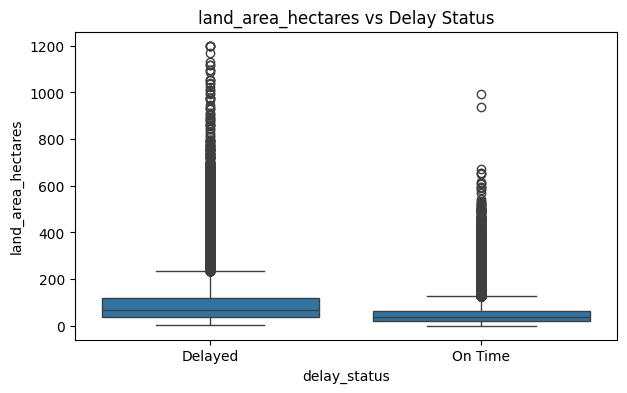

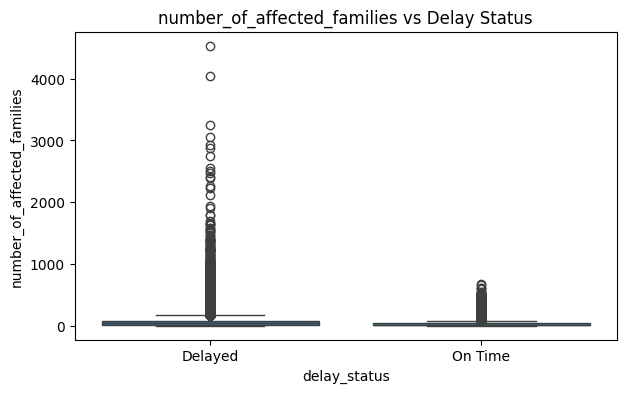

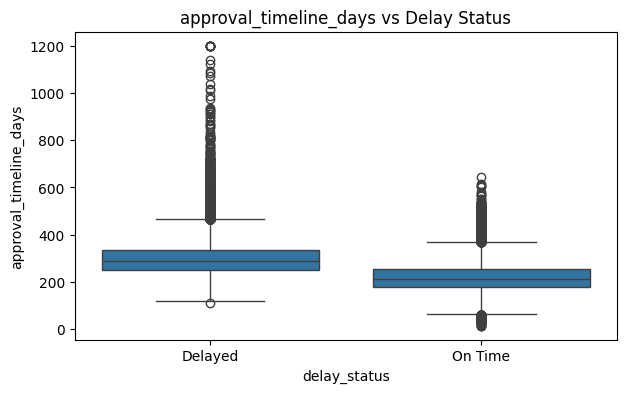

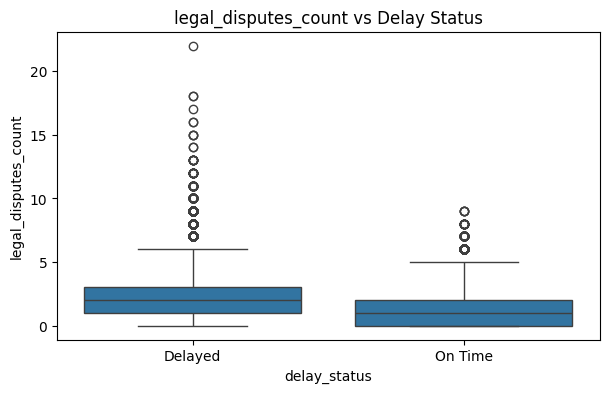

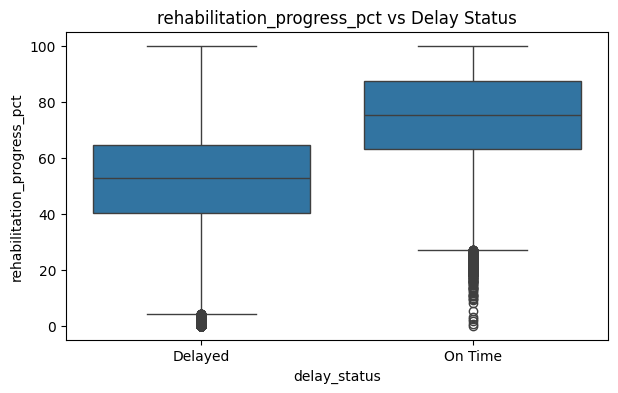

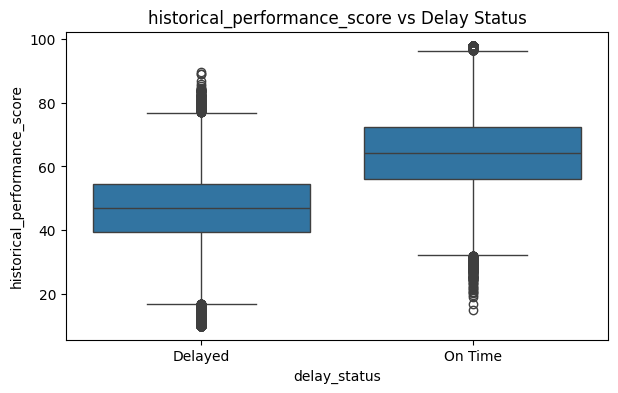

In [31]:
important_numeric = [
    "land_area_hectares",
    "number_of_affected_families",
    "approval_timeline_days",
    "legal_disputes_count",
    "rehabilitation_progress_pct",
    "historical_performance_score"
]

for col in important_numeric:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="delay_status",
        y=col
    )

    plt.title(f"{col} vs Delay Status")
    plt.show()

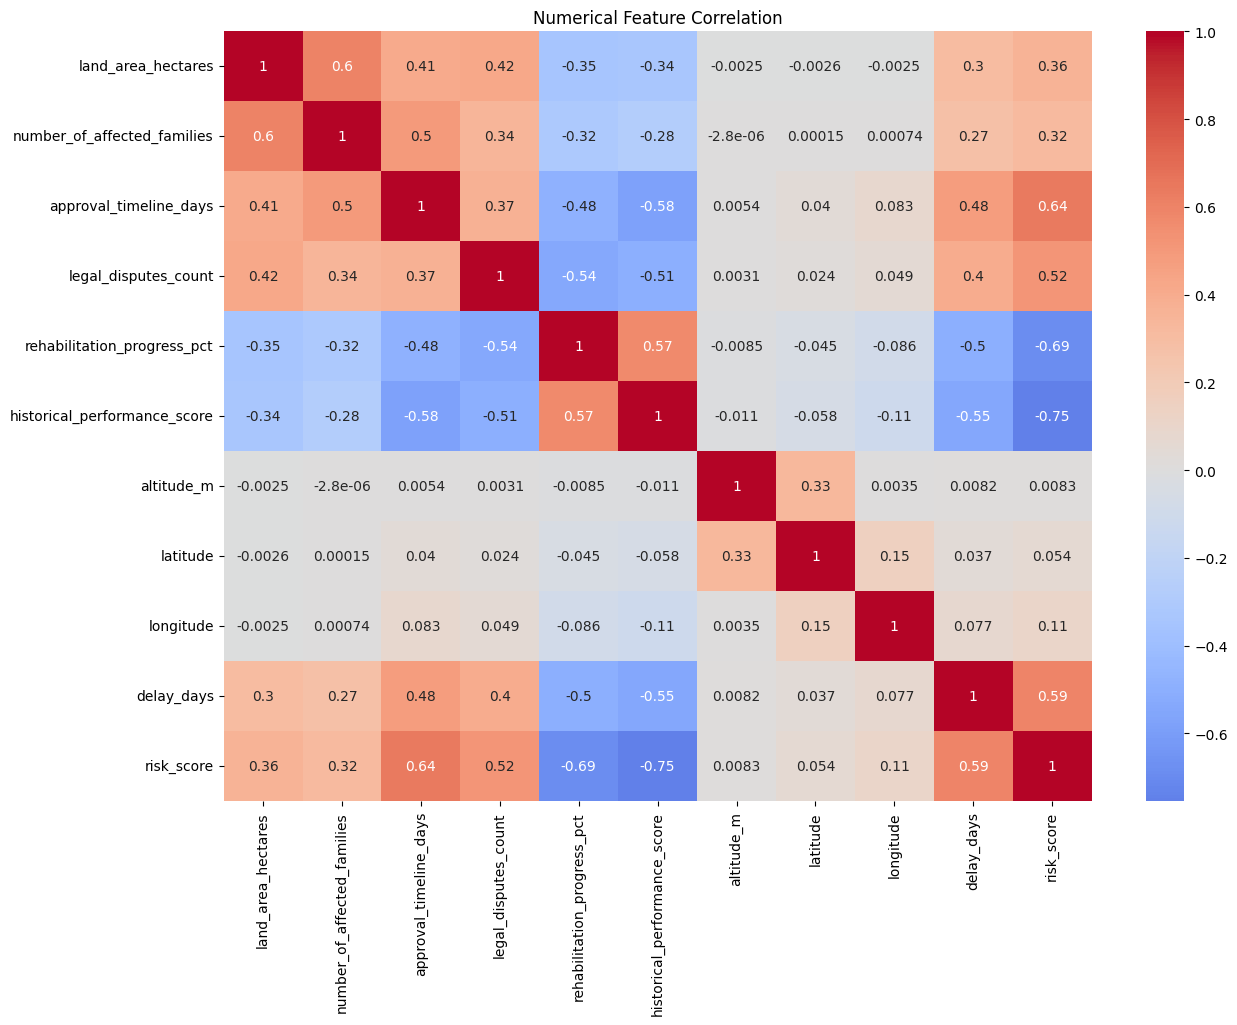

In [32]:
corr = df[numerical_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
)

plt.title("Numerical Feature Correlation")
plt.show()

In [33]:
potential_target_related = [
    "delay_status",
    "delay_days",
    "risk_score"
]

df[potential_target_related].corr(numeric_only=True)

,delay_days,risk_score
delay_days,1.000000,0.591711
risk_score,0.591711,1.000000


### Geographic EDA

In [34]:
df[["latitude", "longitude", "altitude_m"]].describe()

,latitude,longitude,altitude_m
count,200000.000000,200000.000000,200000.000000
mean,22.269698,80.160722,448.412172
std,5.903773,5.919266,510.092214
min,10.566700,69.475257,0.000000
25%,18.112400,75.880617,128.400000
50%,22.973400,78.703178,331.800000
75%,26.846700,84.368628,573.625000
max,34.152600,96.847433,4293.100000


In [35]:
print("Invalid latitude:",
      ((df["latitude"] < -90) | (df["latitude"] > 90)).sum())

print("Invalid longitude:",
      ((df["longitude"] < -180) | (df["longitude"] > 180)).sum())

Invalid latitude: 0
Invalid longitude: 0


In [36]:
df["location"].value_counts().head(20)

location
Nashik, Maharashtra             2748
Nagpur, Maharashtra             2714
Pune, Maharashtra               2707
Mumbai Suburban, Maharashtra    2706
Raigad, Maharashtra             2683
Thane, Maharashtra              2603
Belagavi, Karnataka             2561
Indore, Madhya Pradesh          2554
Mysuru, Karnataka               2547
Jabalpur, Madhya Pradesh        2522
Gwalior, Madhya Pradesh         2519
Bhopal, Madhya Pradesh          2507
Bengaluru Urban, Karnataka      2502
Mangaluru, Karnataka            2492
Vadodara, Gujarat               2074
Bhagalpur, Bihar                2072
Tiruppur, Tamil Nadu            2070
Kanpur Nagar, Uttar Pradesh     2069
Gorakhpur, Uttar Pradesh        2061
Muzaffarpur, Bihar              2056
Name: count, dtype: int64

### Outlier investigation

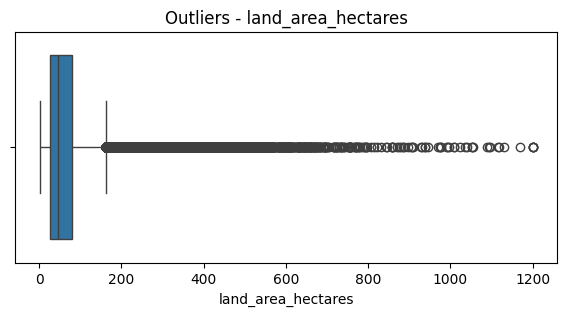

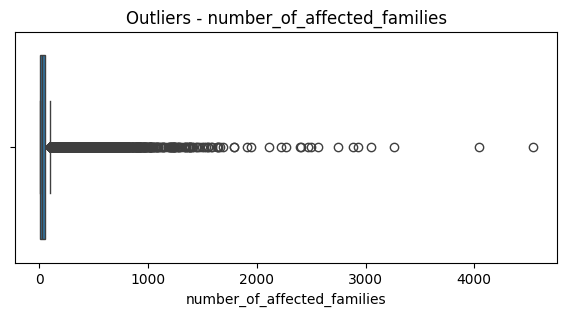

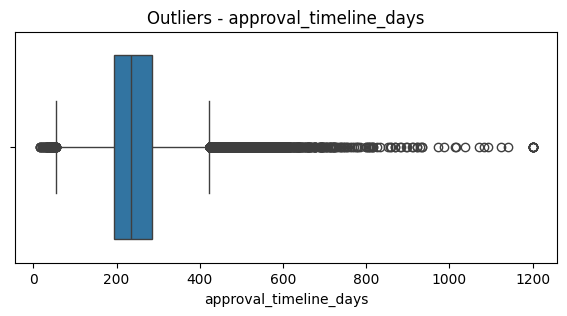

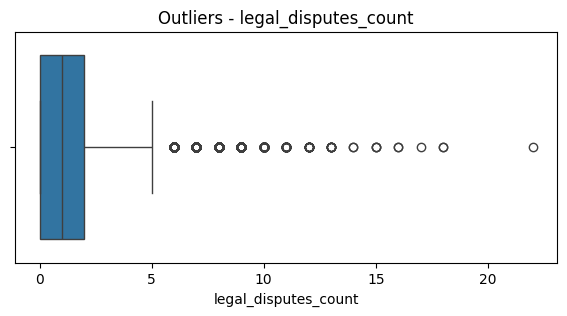

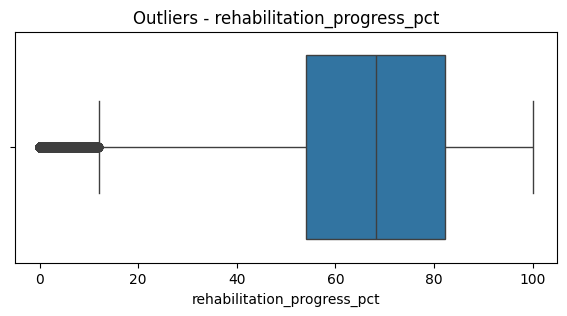

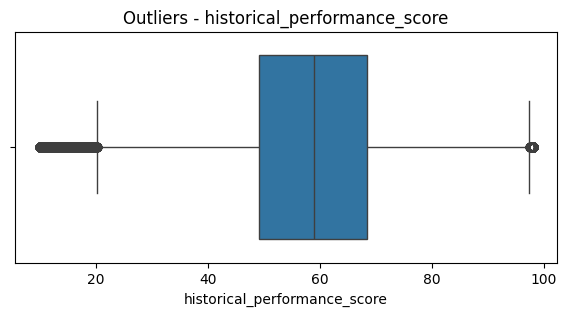

In [37]:
for col in important_numeric:

    plt.figure(figsize=(7, 3))

    sns.boxplot(x=df[col])

    plt.title(f"Outliers - {col}")
    plt.show()